# Entrega 2 — Análise preliminar de furtos e roubos na Grande Vitória

**Disciplina:** Projeto Integrador III  

**Tema:** Análise preliminar de furtos e roubos na Grande Vitória 

**Grupo:** Alexsander, Ester, Larissa Moraes, Lucas Rufino, Marcelo Mindas, Vanderson de Almeida  

**Data:** Maio de 2026

---

## Objetivo deste notebook

Este notebook organiza a Entrega 2 do projeto, com foco em construir um protótipo funcional de análise de dados. A análise parte dos microdados de ocorrências, aplica o recorte definido pelo grupo e gera visualizações preliminares para identificar padrões de furtos e roubos na Grande Vitória, especialmente em relação ao horário das ocorrências.

O notebook está organizado para responder às seguintes perguntas:

1. A base contém as colunas necessárias para o projeto?
2. Quantas ocorrências permanecem após aplicar o recorte de período, municípios e tipos de crime?
3. Como furtos e roubos se distribuem por município, mês, dia da semana e hora?
4. Existem diferenças visíveis entre o padrão horário de furtos e roubos?
5. Um baseline simples consegue servir como referência inicial para a próxima etapa de modelagem?


## Bibliotecas utilizadas


In [5]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)


## Configurações gerais do projeto


In [6]:

# Municípios que compõem o recorte da Grande Vitória usado no projeto.
municipios_gv = [
    "VITORIA",
    "VILA VELHA",
    "SERRA",
    "CARIACICA",
    "VIANA",
    "GUARAPARI",
    "FUNDAO",
]

# Recorte temporal definido para a análise preliminar.
dt_inicio = pd.Timestamp("2021-03-01")
dt_fim = pd.Timestamp("2026-04-30")

ordem_dias = [
    "Segunda-feira",
    "Terça-feira",
    "Quarta-feira",
    "Quinta-feira",
    "Sexta-feira",
    "Sábado",
    "Domingo",
]

traducao_dias = {
    "Monday": "Segunda-feira",
    "Tuesday": "Terça-feira",
    "Wednesday": "Quarta-feira",
    "Thursday": "Quinta-feira",
    "Friday": "Sexta-feira",
    "Saturday": "Sábado",
    "Sunday": "Domingo",
}


## Carregamento dos dados


In [7]:
dados = pd.read_csv("../dados/MICRODADOS_OCORRENCIAS.csv", sep=';', encoding='latin-1')
dados.sample(10, random_state=42)

,Data,Hora,TipoIncidente,TipoLocal,Municipio,Bairro
305481,16/06/2022,18:52:00,ROUBO: A PESSOA EM VIA PÚBLICA,VIA PÚBLICA,VILA VELHA,DIVINO ESPIRITO SANTO
410545,08/02/2021,15:12:00,ROUBO: EM ESTABELECIMENTO COMERCIAL,COMÉRCIO,SERRA,PARQUE RESIDENCIAL LARANJEIRAS
383403,06/07/2021,Indeterminada,ESTELIONATO/FRAUDE,AMBIENTE WEB,VITORIA,JUCUTUQUARA
313304,13/05/2022,22:00:00,ROUBO: A PESSOA EM VIA PÚBLICA,VIA PÚBLICA,CARIACICA,CAMPO GRANDE
185279,12/12/2023,Indeterminada,ESTELIONATO/FRAUDE,AMBIENTE WEB,GUARAPARI,OUTRO LOCAL
296597,27/07/2022,00:00:00,ESTELIONATO/FRAUDE,NaN,SERRA,JARDIM LIMOEIRO
190848,17/11/2023,15:30:00,ESTELIONATO/FRAUDE,AMBIENTE WEB,MIMOSO DO SUL,SANTA ROSA
288033,03/09/2022,18:00:00,ROUBO: A PESSOA EM VIA PÚBLICA,VIA PÚBLICA,CARIACICA,CAMPO GRANDE
361819,21/10/2021,17:30:00,ROUBO: A PESSOA EM VIA PÚBLICA,VIA PÚBLICA,CARIACICA,CAMPO GRANDE
486620,17/11/2019,16:40:00,ROUBO: A PESSOA EM VIA PÚBLICA,VIA PÚBLICA,VIANA,CANAA


## Visualização inicial da base


In [8]:

print("Dimensão da base original:")
print(f"Linhas: {dados.shape[0]:,}".replace(",", "."))
print(f"Colunas: {dados.shape[1]}")

print("\nColunas disponíveis:")
display(pd.DataFrame({"coluna": dados.columns}))

print("\nAmostra da base original:")
display(dados.sample(10, random_state=42))

Dimensão da base original:
Linhas: 617.940
Colunas: 6

Colunas disponíveis:


,coluna
0,Data
1,Hora
2,TipoIncidente
3,TipoLocal
4,Municipio
5,Bairro



Amostra da base original:


,Data,Hora,TipoIncidente,TipoLocal,Municipio,Bairro
305481,16/06/2022,18:52:00,ROUBO: A PESSOA EM VIA PÚBLICA,VIA PÚBLICA,VILA VELHA,DIVINO ESPIRITO SANTO
410545,08/02/2021,15:12:00,ROUBO: EM ESTABELECIMENTO COMERCIAL,COMÉRCIO,SERRA,PARQUE RESIDENCIAL LARANJEIRAS
383403,06/07/2021,Indeterminada,ESTELIONATO/FRAUDE,AMBIENTE WEB,VITORIA,JUCUTUQUARA
313304,13/05/2022,22:00:00,ROUBO: A PESSOA EM VIA PÚBLICA,VIA PÚBLICA,CARIACICA,CAMPO GRANDE
185279,12/12/2023,Indeterminada,ESTELIONATO/FRAUDE,AMBIENTE WEB,GUARAPARI,OUTRO LOCAL
296597,27/07/2022,00:00:00,ESTELIONATO/FRAUDE,NaN,SERRA,JARDIM LIMOEIRO
190848,17/11/2023,15:30:00,ESTELIONATO/FRAUDE,AMBIENTE WEB,MIMOSO DO SUL,SANTA ROSA
288033,03/09/2022,18:00:00,ROUBO: A PESSOA EM VIA PÚBLICA,VIA PÚBLICA,CARIACICA,CAMPO GRANDE
361819,21/10/2021,17:30:00,ROUBO: A PESSOA EM VIA PÚBLICA,VIA PÚBLICA,CARIACICA,CAMPO GRANDE
486620,17/11/2019,16:40:00,ROUBO: A PESSOA EM VIA PÚBLICA,VIA PÚBLICA,VIANA,CANAA


In [9]:

print("Informações gerais da base:")
dados.info()

Informações gerais da base:
<class 'pandas.DataFrame'>
RangeIndex: 617940 entries, 0 to 617939
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Data           617940 non-null  str  
 1   Hora           617940 non-null  str  
 2   TipoIncidente  617940 non-null  str  
 3   TipoLocal      535736 non-null  str  
 4   Municipio      617940 non-null  str  
 5   Bairro         617940 non-null  str  
dtypes: str(6)
memory usage: 28.3 MB


In [10]:

print("Quantidade de valores ausentes por coluna:")
display(dados.isna().sum().sort_values(ascending=False).to_frame("qtd_ausentes"))

Quantidade de valores ausentes por coluna:


,qtd_ausentes
TipoLocal,82204
Data,0
Hora,0
TipoIncidente,0
Municipio,0
Bairro,0


## Tratamento inicial dos dados


In [11]:

# Cópia de trabalho para preservar a base original carregada.
dados_trat = dados.copy()

# Padronização de texto
colunas_texto = ["TipoIncidente", "TipoLocal", "Municipio", "Bairro"]

for coluna in colunas_texto:
    if coluna in dados_trat.columns:
        dados_trat[coluna] = (
            dados_trat[coluna]
            .astype("string")
            .str.strip()
            .str.upper()
        )

In [12]:

# Conversão da data.
dados_trat["DataOriginal"] = dados_trat["Data"]
dados_trat["Data"] = pd.to_datetime(dados_trat["Data"], errors="coerce", dayfirst=True)

print("Datas inválidas após conversão:", dados_trat["Data"].isna().sum())
print("Período original identificado:")
print(dados_trat["Data"].min(), "até", dados_trat["Data"].max())


Datas inválidas após conversão: 0
Período original identificado:
2018-01-01 00:00:00 até 2026-04-30 00:00:00


## Filtragem do escopo do projeto

O recorte do projeto segue três filtros principais:

1. **Período:** aproximadamente últimos 5 anos disponíveis na base;
2. **Municípios:** Grande Vitória;
3. **Tipo de crime:** furtos e roubos.


In [13]:

# Filtro de período
dados_periodo = dados_trat[
    (dados_trat["Data"] >= dt_inicio) &
    (dados_trat["Data"] <= dt_fim)
].copy()

# Filtro de municípios da Grande Vitória
dados_gv = dados_periodo[
    dados_periodo["Municipio"].isin(municipios_gv)
].copy()

# Filtro de furtos e roubos
dados_filtr = dados_gv[
    dados_gv["TipoIncidente"].str.contains("FURTO|ROUBO", na=False)
].copy()

resumo_filtros = pd.DataFrame({
    "etapa": [
        "Base original",
        "Após filtro de período",
        "Após filtro de municípios da GV",
        "Após filtro de furtos e roubos",
    ],
    "linhas": [
        len(dados_trat),
        len(dados_periodo),
        len(dados_gv),
        len(dados_filtr),
    ]
})

resumo_filtros["perc_em_relacao_base_original"] = (
    resumo_filtros["linhas"] / len(dados_trat) * 100
).round(2)

display(resumo_filtros)

print(f"Total no recorte: {len(dados_filtr):,}".replace(",", "."))

,etapa,linhas,perc_em_relacao_base_original
0,Base original,617940,100.00
1,Após filtro de período,406806,65.83
2,Após filtro de municípios da GV,273454,44.25
3,Após filtro de furtos e roubos,120696,19.53


Total no recorte: 120.696


### Leitura do recorte utilizado

Após a aplicação dos filtros de período, municípios da Grande Vitória e tipos de ocorrência relacionados a furto e roubo, a base passou a representar o recorte definido para a Entrega 2.

Esse recorte é importante porque evita que a análise fique ampla demais e mantém o foco do projeto: observar padrões temporais de furtos e roubos na Grande Vitória entre 01/03/2021 e 30/04/2026. De acordo com o processamento realizado, o dataset final conta com 120.698 registros, representando 19,53% da base original.

In [14]:

print("Municípios encontrados após o recorte:")
display(dados_filtr["Municipio"].value_counts().to_frame("ocorrencias"))

print("\nTipos de incidente mais frequentes no recorte:")
display(dados_filtr["TipoIncidente"].value_counts().head(20).to_frame("ocorrencias"))


Municípios encontrados após o recorte:


,ocorrencias
Municipio,
SERRA,33320
VILA VELHA,28833
VITORIA,26135
CARIACICA,24465
GUARAPARI,4987
VIANA,2229
FUNDAO,727



Tipos de incidente mais frequentes no recorte:


,ocorrencias
TipoIncidente,
ROUBO: A PESSOA EM VIA PÚBLICA,59092
FURTO: EM ESTABELECIMENTO COMERCIAL,15016
FURTO: EM RESIDÊNCIA/CONDOMÍNIO,12864
FURTO: A PESSOA EM VIA PÚBLICA,12568
FURTO: EM TRANSPORTE COLETIVO,9067
ROUBO: EM TRANSPORTE COLETIVO,8236
ROUBO: EM ESTABELECIMENTO COMERCIAL,3155
ROUBO: EM RESIDÊNCIA/CONDOMÍNIO,698


## Criação de variáveis derivadas


In [15]:

# Categoria resumida: Furto / Roubo.
def categorizar_crime(tipo):
    if pd.isna(tipo):
        return np.nan
    if "FURTO" in tipo:
        return "Furto"
    if "ROUBO" in tipo:
        return "Roubo"
    return "Outro"


dados_filtr["CategoriaCrime"] = dados_filtr["TipoIncidente"].apply(categorizar_crime)

print("Distribuição por categoria resumida:")
display(dados_filtr["CategoriaCrime"].value_counts().to_frame("ocorrencias"))


Distribuição por categoria resumida:


,ocorrencias
CategoriaCrime,
Roubo,71181
Furto,49515


In [16]:

# Variáveis temporais 
dados_filtr["Ano"] = dados_filtr["Data"].dt.year
dados_filtr["Mes"] = dados_filtr["Data"].dt.month
dados_filtr["NomeMes"] = dados_filtr["Data"].dt.month_name(locale=None)
dados_filtr["AnoMes"] = dados_filtr["Data"].dt.to_period("M")
dados_filtr["DiaSemana"] = dados_filtr["Data"].dt.day_name().map(traducao_dias)

dados_filtr["DiaSemana"] = pd.Categorical(
    dados_filtr["DiaSemana"],
    categories=ordem_dias,
    ordered=True
)

display(dados_filtr[["Data", "Ano", "Mes", "AnoMes", "DiaSemana"]].head())


,Data,Ano,Mes,AnoMes,DiaSemana
23,2026-04-30,2026,4,2026-04,Quinta-feira
33,2026-04-30,2026,4,2026-04,Quinta-feira
37,2026-04-30,2026,4,2026-04,Quinta-feira
39,2026-04-30,2026,4,2026-04,Quinta-feira
45,2026-04-30,2026,4,2026-04,Quinta-feira


In [17]:
# Tratamento da hora.
dados_filtr["HoraOriginal"] = dados_filtr["Hora"]
dados_filtr["HoraConvertida"] = pd.to_datetime(
    dados_filtr["Hora"].astype("string").str.strip(),
    format="%H:%M:%S",
    errors="coerce"
)

dados_filtr["HoraDia"] = dados_filtr["HoraConvertida"].dt.hour.astype("Int64")

# Faixas horárias para facilitar interpretação.
dados_filtr["FaixaHorario"] = pd.cut(
    dados_filtr["HoraDia"].astype("float"),
    bins=[0, 6, 12, 18, 24],
    labels=[
        "Madrugada (00h-05h)",
        "Manhã (06h-11h)",
        "Tarde (12h-17h)",
        "Noite (18h-23h)",
    ],
    right=False,
)

qtd_hora_invalida = dados_filtr["HoraDia"].isna().sum()
perc_hora_invalida = qtd_hora_invalida / len(dados_filtr) * 100

print(f"Registros no recorte: {len(dados_filtr):,}".replace(",", "."))
print(f"Registros sem hora válida: {qtd_hora_invalida:,} ({perc_hora_invalida:.2f}%)".replace(",", "."))

dados_hora = dados_filtr.dropna(subset=["HoraDia"]).copy()
dados_hora["HoraDia"] = dados_hora["HoraDia"].astype(int)

print(f"Registros usados nas análises por hora: {len(dados_hora):,}".replace(",", "."))


Registros no recorte: 120.696
Registros sem hora válida: 7.015 (5.81%)
Registros usados nas análises por hora: 113.681


### Criação de Variáveis Derivadas
Para entender melhor o comportamento dos crimes ao longo do tempo, transformamos os dados originais em variáveis mais específicas, como ano, mês, dia da semana e faixas horárias. Isso nos permite identificar o que chamamos de "Mancha Criminal Temporal".

Um detalhe importante é a qualidade dessas informações: apenas 5,81% dos registros estão sem o horário da ocorrência. Isso é excelente, pois dá muito mais segurança e precisão para as análises que faremos nas próximas etapas.

Ao analisar essas faixas, conseguiremos observar se crimes específicos se concentram nos horários de pico. Se essa tendência se confirmar, os dados indicarão que o criminoso aproveita a maior aglomeração de pessoas e as janelas de rotina para agir.

## 8. Análise exploratória


In [18]:

def grafico_barras(serie, titulo, xlabel="", ylabel="Quantidade de ocorrências", rotacao=45, tamanho=(10, 5)):
    # Função para padronizar gráficos de barras.
    plt.figure(figsize=tamanho)
    ax = serie.plot(kind="bar")
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotacao, ha="right")
    plt.tight_layout()
    plt.show()


### 8.1 Ocorrências por tipo de crime


,ocorrencias
TipoIncidente,
ROUBO: A PESSOA EM VIA PÚBLICA,59092
FURTO: EM ESTABELECIMENTO COMERCIAL,15016
FURTO: EM RESIDÊNCIA/CONDOMÍNIO,12864
FURTO: A PESSOA EM VIA PÚBLICA,12568
FURTO: EM TRANSPORTE COLETIVO,9067
ROUBO: EM TRANSPORTE COLETIVO,8236
ROUBO: EM ESTABELECIMENTO COMERCIAL,3155
ROUBO: EM RESIDÊNCIA/CONDOMÍNIO,698


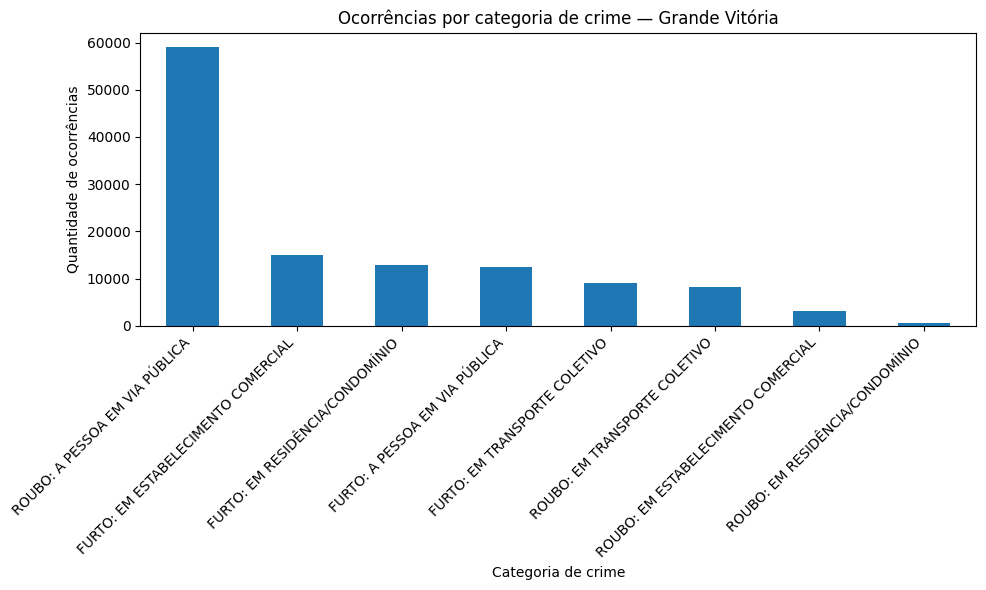

Categoria mais frequente: ROUBO: A PESSOA EM VIA PÚBLICA (59.092 registros)


In [19]:

serie_categoria = dados_filtr["TipoIncidente"].value_counts()
display(serie_categoria.to_frame("ocorrencias"))

grafico_barras(
    serie_categoria,
    "Ocorrências por categoria de crime — Grande Vitória",
    xlabel="Categoria de crime",
    rotacao=45,
    tamanho=(10, 6)
)

categoria_mais_freq = serie_categoria.idxmax()
qtd_categoria_mais_freq = int(serie_categoria.max())

print(f"Categoria mais frequente: {categoria_mais_freq} ({qtd_categoria_mais_freq:,} registros)".replace(",", "."))


### Distribuição por Modalidade de Crime
Ao olhar para os números, fica claro onde os crimes acontecem com mais frequência, o que ajuda muito a entender onde a prevenção precisa ser reforçada.

Predomínio da Via Pública: O "Roubo a pessoa em via pública" lidera as estatísticas com 59.093 registros. Este volume evidencia que o deslocamento urbano é o cenário de maior vulnerabilidade, concentrando quase 50% de todas as ocorrências do recorte.

Vulnerabilidade Comercial: O "Furto em estabelecimento comercial" surge como a segunda categoria mais relevante (15.017 casos). Diferente do roubo à pessoa, essa modalidade aponta para uma dinâmica de oportunidade no setor varejista, exigindo estratégias de segurança bem diferentes do policiamento de rua comum.

Comparativo: Dinâmicas de Furto vs. Roubo
A distinção entre furto e roubo é fundamental para a modelagem preditiva deste projeto, uma vez que as duas naturezas criminais operam sob lógicas diferentes:

Natureza da Ocorrência: Enquanto o roubo é pautado pela abordagem direta e violência (ou ameaça), o furto depende da ausência de vigilância.

O que queremos descobrir: Separar essas categorias permite identificar se os picos de criminalidade coincidem nos mesmos horários e locais ou se cada modalidade possui um "ciclo de oportunidade" próprio. Essa diferenciação será o alicerce para os modelos de tendência que serão desenvolvidos na próxima etapa.

### 8.2 Ocorrências por município


,ocorrencias
Municipio,
SERRA,33320
VILA VELHA,28833
VITORIA,26135
CARIACICA,24465
GUARAPARI,4987
VIANA,2229
FUNDAO,727


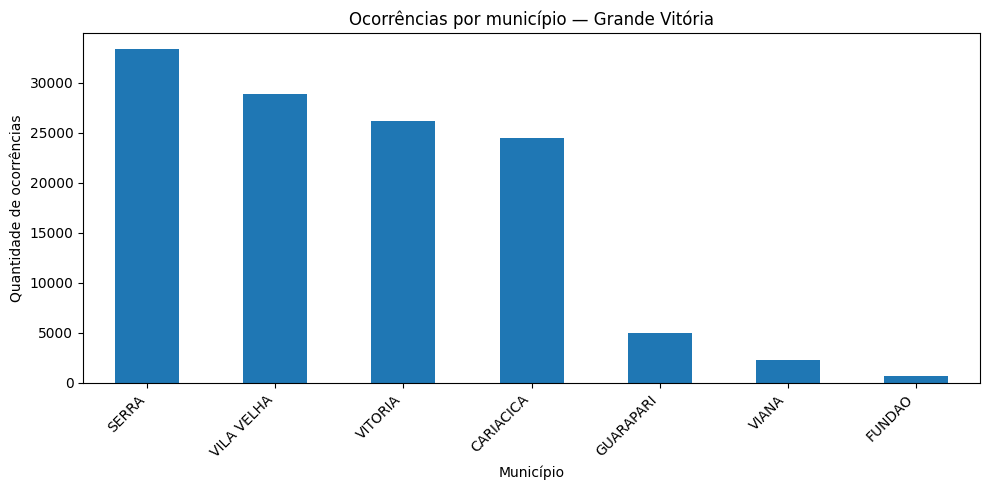

Município com maior contagem absoluta: SERRA (33.320 registros)


In [20]:

serie_municipio = dados_filtr["Municipio"].value_counts()
display(serie_municipio.to_frame("ocorrencias"))

grafico_barras(
    serie_municipio,
    "Ocorrências por município — Grande Vitória",
    xlabel="Município",
    rotacao=45,
    tamanho=(10, 5)
)

maior_municipio = serie_municipio.idxmax()
qtd_maior_municipio = int(serie_municipio.max())

print(f"Município com maior contagem absoluta: {maior_municipio} ({qtd_maior_municipio:,} registros)".replace(",", "."))


###  Ocorrências por Município
O gráfico mostra como os crimes estão distribuídos pelas cidades da Grande Vitória. Como esperado, os municípios maiores concentram a maioria dos registros, mas é importante lembrar que esses são números brutos.

Destaques por cidade: A Serra lidera o volume com 33.320 registros, vindo depois Vila Velha (28.834), Vitória (26.135) e Cariacica (24.466). Essas quatro cidades juntas somam a maior parte do nosso recorte.

Ter mais ocorrências não significa necessariamente que uma cidade é mais perigosa que a outra. Como elas têm populações muito grandes, o volume total acaba sendo naturalmente maior.

Para termos uma visão mais justa do risco em cada local, o ideal seria cruzar esses dados com o número de habitantes e calcular taxas por 100 mil pessoas. Essa é uma análise que pode trazer resultados bem diferentes e que pretendemos aprofundar na próxima entrega.

### 8.3 Série mensal de ocorrências


,AnoMes,ocorrencias,AnoMesData
0,2021-03,2213,2021-03-01
1,2021-04,1744,2021-04-01
2,2021-05,1904,2021-05-01
3,2021-06,2089,2021-06-01
4,2021-07,2167,2021-07-01


,AnoMes,ocorrencias,AnoMesData
57,2025-12,1194,2025-12-01
58,2026-01,1399,2026-01-01
59,2026-02,1588,2026-02-01
60,2026-03,1423,2026-03-01
61,2026-04,1117,2026-04-01


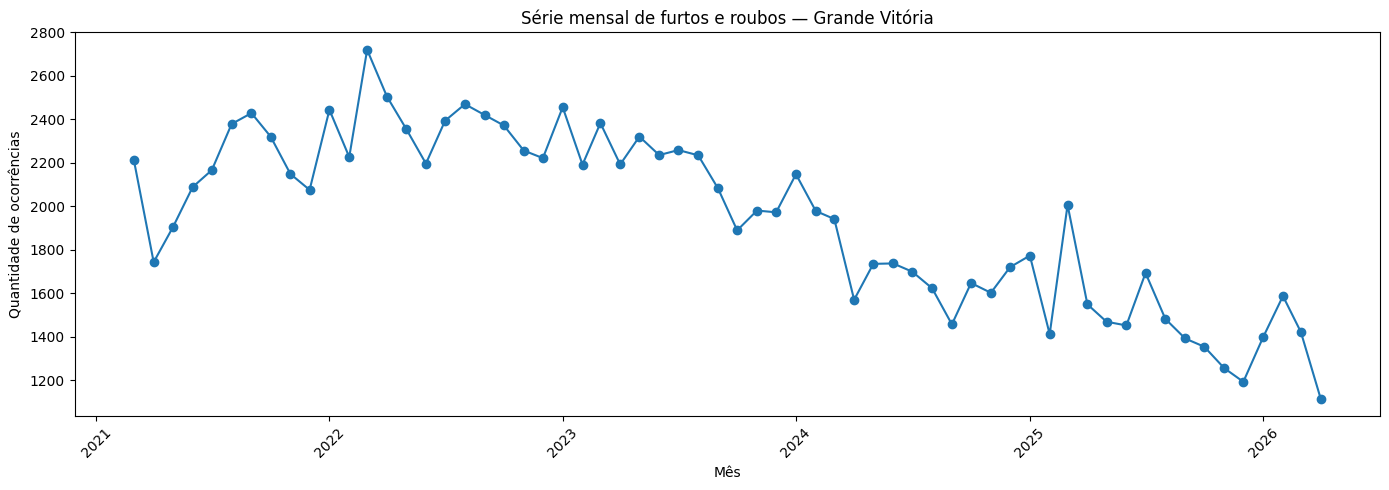

In [21]:

serie_ano_mes = (
    dados_filtr
    .groupby("AnoMes")
    .size()
    .rename("ocorrencias")
    .reset_index()
)
serie_ano_mes["AnoMesData"] = serie_ano_mes["AnoMes"].dt.to_timestamp()

display(serie_ano_mes.head())
display(serie_ano_mes.tail())

plt.figure(figsize=(14, 5))
plt.plot(serie_ano_mes["AnoMesData"], serie_ano_mes["ocorrencias"], marker="o")
plt.title("Série mensal de furtos e roubos — Grande Vitória")
plt.xlabel("Mês")
plt.ylabel("Quantidade de ocorrências")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Série mensal de ocorrências

A visualização da série mensal permite acompanhar como os crimes variaram ao longo desses cinco anos. Olhando para o gráfico, percebemos que as ocorrências não são constantes: existem picos claros e períodos de maior estabilidade, além de uma aparente tendência de queda no volume total conforme avançamos para os anos mais recentes. 

Entender esse comportamento é fundamental para a nossa próxima etapa, a de modelagem. Como o nosso baseline vai trabalhar com contagens mensais, identificar essas oscilações ajuda a avaliar se o modelo conseguirá captar as tendências reais dos dados. 

Por enquanto, a análise mostra que o crime segue uma dinâmica temporal própria, o que reforça que não podemos olhar para os dados de forma isolada, mas sim como um fluxo contínuo ao longo dos meses.  

### 8.4 Ocorrências por mês do ano


,ocorrencias
Mes,
1,10221
2,9399
3,12688
4,10680
5,9788
6,9713
7,10214
8,10191
9,9783


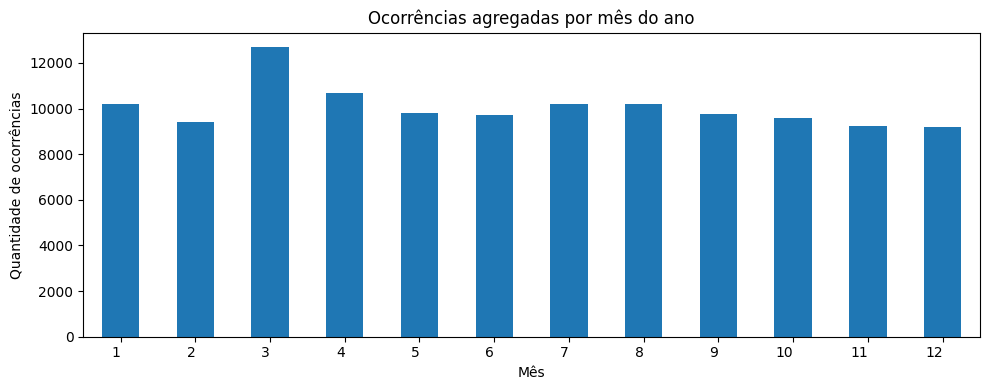

Mês com maior volume acumulado: Março (12.688 registros)


In [22]:
dados_filtr['Data'] = pd.to_datetime(dados_filtr['Data'])
dados_filtr['Mes'] = dados_filtr['Data'].dt.month

serie_mes = dados_filtr["Mes"].value_counts().sort_index()
display(serie_mes.to_frame("ocorrencias"))

grafico_barras(
    serie_mes,
    "Ocorrências agregadas por mês do ano",
    xlabel="Mês",
    rotacao=0,
    tamanho=(10, 4)
)

print(f"Mês com maior volume acumulado: Março ({serie_mes.max():,d} registros)".replace(",", "."))

### Ocorrências por mês do ano

A análise por mês do ano agrupa as ocorrências de todos os anos e ajuda a observar possíveis indícios de sazonalidade. Diferente da série mensal, que mostra a evolução mês a mês ao longo do tempo, este gráfico permite comparar os meses somando todos os anos do período.

Pico em Março: O mês de março (3) se destaca com o maior volume acumulado, chegando a 12.688 ocorrências.

Distribuição: Logo após março, vemos um volume alto em abril (10.682), mas o restante do ano se mantém em um patamar mais equilibrado, com os menores índices aparecendo no final do ano, como em dezembro (9.186).

Essa análise ainda não confirma sazonalidade estatisticamente, mas ajuda a levantar hipóteses para a próxima etapa do projeto.

### 8.5 Ocorrências por dia da semana


,ocorrências
DiaSemana,
Segunda-feira,19026
Terça-feira,18341
Quarta-feira,17970
Quinta-feira,17641
Sexta-feira,17466
Sábado,16078
Domingo,14174


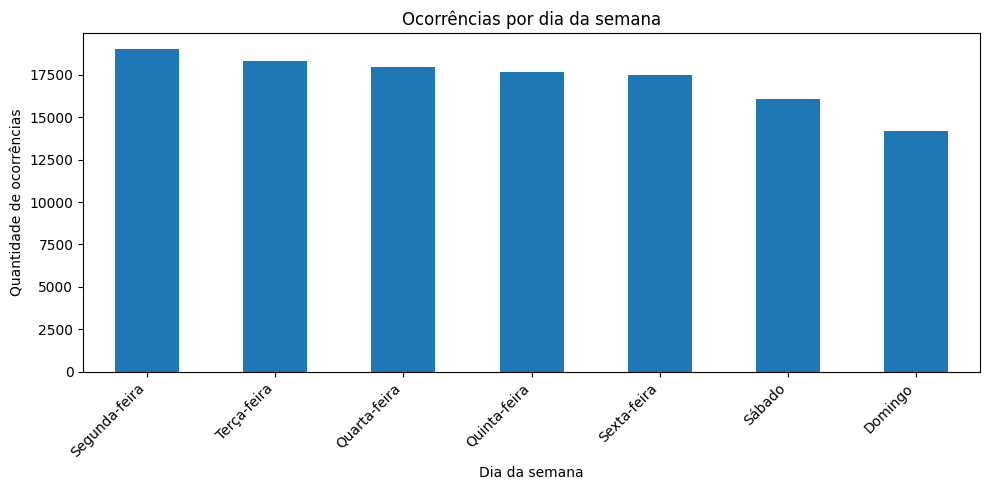

Dia da semana com maior contagem: Segunda-feira (19.026 registros)


In [23]:
dados_filtr['Data'] = pd.to_datetime(dados_filtr['Data'])
dados_filtr['DiaSemana'] = dados_filtr['Data'].dt.day_name().map(traducao_dias)

ordem_dias = ["Segunda-feira", "Terça-feira", "Quarta-feira", "Quinta-feira", "Sexta-feira", "Sábado", "Domingo"]
serie_dia = dados_filtr["DiaSemana"].value_counts().reindex(ordem_dias)
display(serie_dia.to_frame("ocorrências"))

grafico_barras(
    serie_dia,
    "Ocorrências por dia da semana",
    xlabel="Dia da semana",
    rotacao=45,
    tamanho=(10, 5)
)
maior_dia = serie_dia.idxmax()
qtd_maior_dia = serie_dia.max()

print(f"Dia da semana com maior contagem: {maior_dia} ({qtd_maior_dia:,.0f} registros)".replace(",", "."))

### Ocorrências por dia da semana
Este gráfico ajuda a entender como os crimes se distribuem ao longo da semana e se existem dias com maior concentração. Essa análise é interessante porque pode indicar uma relação direta com a rotina da cidade, como os dias de maior movimento no comércio ou o fluxo de pessoas indo e voltando do trabalho.

Início de semana mais movimentado: A Segunda-feira lidera as estatísticas com 19.026 registros, seguida de perto pela Terça-feira (18.341).

Queda no final de semana: O volume de ocorrências vai diminuindo gradualmente conforme o final de semana chega, atingindo o ponto mais baixo no Domingo, com 14.174 casos.

Os números mostram um padrão claro: o volume de crimes é significativamente maior nos dias úteis do que no descanso. Por enquanto, tratamos esses dados como uma análise descritiva que reflete o comportamento dos incidentes dentro do recorte de tempo que escolhemos.

### 8.6 Ocorrências por hora do dia


,ocorrencias
HoraDia,
0,3704
1,2138
2,2469
3,2475
4,3172
5,5490
6,5143
7,4376
8,3792


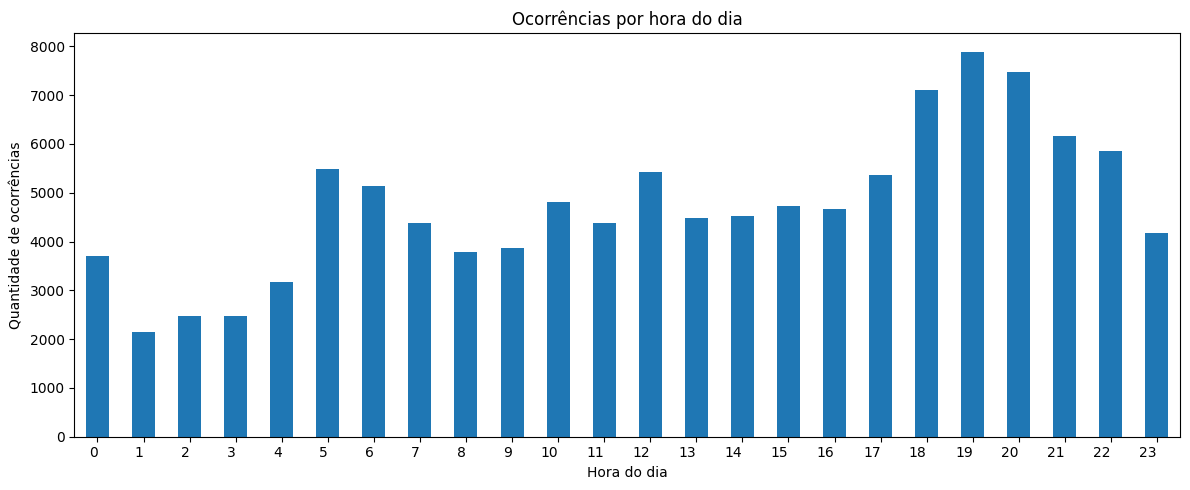

Hora com maior contagem geral: 19h (7.882 registros)


In [24]:

serie_hora = dados_hora["HoraDia"].value_counts().sort_index()
serie_hora = serie_hora.reindex(range(24), fill_value=0)

display(serie_hora.to_frame("ocorrencias"))

grafico_barras(
    serie_hora,
    "Ocorrências por hora do dia",
    xlabel="Hora do dia",
    rotacao=0,
    tamanho=(12, 5)
)

maior_hora = int(serie_hora.idxmax())
qtd_maior_hora = int(serie_hora.max())

print(f"Hora com maior contagem geral: {maior_hora}h ({qtd_maior_hora:,} registros)".replace(",", "."))


### Ocorrências por hora do dia

A distribuição por hora permite identificar janelas bem específicas onde os crimes se concentram, refletindo a dinâmica de movimentação da cidade.

Pico Noturno: O horário com maior volume de registros é às 19h, alcançando 7.882 ocorrências. Esse pico se estende entre as 18h e 20h, coincidindo com o período de saída do trabalho e faculdade, quando há mais gente circulando nas ruas.

Pico da Manhã: Existe um segundo momento crítico por volta das 5h e 6h da manhã, que soma mais de 10.000 registros. Isso sugere uma alta vulnerabilidade no início do dia, possivelmente ligada à saída das pessoas para o trabalho.

Madrugada e Almoço: Os horários de menor movimento (entre 1h e 4h da manhã) são os que apresentam menos registros, enquanto o horário do almoço (12h) mostra um pequeno aumento isolado no volume de casos.

Como alguns registros possuem horário indeterminado, a análise por hora considera apenas ocorrências com horário válido.

### 8.7 Comparação do padrão horário: furto x roubo


CategoriaCrime,Furto,Roubo
HoraDia,,
0,1860,1844
1,1193,945
2,1663,806
3,1723,752
4,1226,1946
5,891,4599
6,1329,3814
7,1741,2635
8,1771,2021


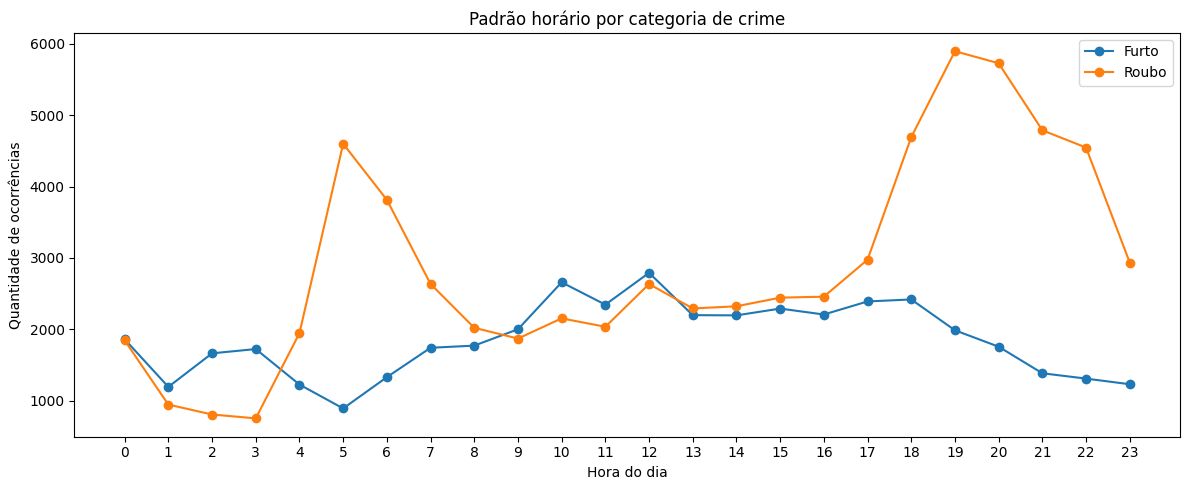

Pico de Roubo: 19h (5.896 registros)
Pico de Furto: 12h (2.791 registros)


In [25]:

hora_categoria = (
    dados_hora
    .groupby(["HoraDia", "CategoriaCrime"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(24), fill_value=0)
)

display(hora_categoria)

plt.figure(figsize=(12, 5))
for categoria in hora_categoria.columns:
    plt.plot(hora_categoria.index, hora_categoria[categoria], marker="o", label=categoria)

plt.title("Padrão horário por categoria de crime")
plt.xlabel("Hora do dia")
plt.ylabel("Quantidade de ocorrências")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

pico_roubo = hora_categoria['Roubo'].idxmax()
pico_furto = hora_categoria['Furto'].idxmax()

print(f"Pico de Roubo: {pico_roubo}h ({hora_categoria['Roubo'].max():,d} registros)".replace(",", "."))
print(f"Pico de Furto: {pico_furto}h ({hora_categoria['Furto'].max():,d} registros)".replace(",", "."))

### Comparação do padrão horário: furto x roubo

Ao comparar furto e roubo por hora do dia, é possível observar que as duas categorias não apresentam exatamente o mesmo comportamento temporal.

Essa diferença reforça a importância de não tratar todos os crimes contra o patrimônio como um único grupo. Separar furto e roubo permite identificar padrões mais específicos e úteis para a interpretação dos dados.

Roubo: O roubo é muito mais agressivo nos horários de pico. Ele apresenta uma subida brusca às 5h da manhã (4.599 registros) e o maior pico de todos às 19h (5.882 registros). São horários de transição (ida e volta do trabalho) onde a abordagem direta parece ser mais frequente.

Furto: Já o furto é mais "espalhado" e constante ao longo do dia. Ele atinge seu ponto mais alto às 12h (2.791 registros) e às 10h (2.668 registros), períodos em que o comércio está a pleno vapor e há situações de descuido ou ausência de vigilância.

Enquanto o roubo se concentra no início e no fim do dia, o furto ganha força no horário comercial e no almoço. Identificar esses ciclos horários específicos é o que permite entender melhor a dinâmica criminal da Grande Vitória.

### 8.8 Ocorrências por faixa horária


,ocorrencias
FaixaHorario,
Madrugada (00h-05h),19448
Manhã (06h-11h),26372
Tarde (12h-17h),29194
Noite (18h-23h),38667


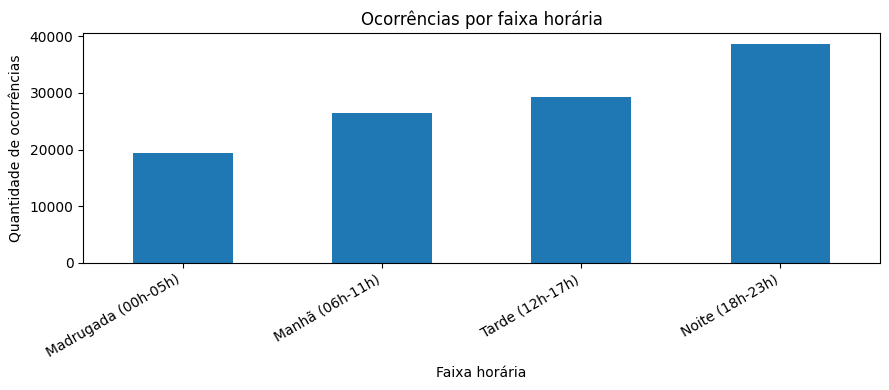

In [26]:
ordem_faixas = [
    "Madrugada (00h-05h)",
    "Manhã (06h-11h)",
    "Tarde (12h-17h)",
    "Noite (18h-23h)",
]

serie_faixa = dados_filtr["FaixaHorario"].value_counts().reindex(ordem_faixas)
display(serie_faixa.to_frame("ocorrencias"))

grafico_barras(
    serie_faixa,
    "Ocorrências por faixa horária",
    xlabel="Faixa horária",
    rotacao=30,
    tamanho=(9, 4)
)


### Ocorrências por faixa horária

A análise por faixa horária resume o comportamento das ocorrências em períodos mais fáceis de interpretar: madrugada, manhã, tarde e noite. Esse agrupamento ajuda a transformar a variação detalhada em uma leitura prática sobre os turnos do dia.

Noite: A faixa da Noite (18h-23h) concentra o maior volume de registros, com 38.668 ocorrências. Isso reforça a observação anterior de que o encerramento do horário comercial e o deslocamento noturno são os períodos de maior incidência.

Dia: As faixas da Tarde (12h-17h) e Manhã (06h-11h) apresentam volumes significativos e próximos, com 29.195 e 26.372 registros, respectivamente.

Madrugada: A Madrugada (00h-05h) aparece com o menor volume acumulado (19.448 ocorrências), mantendo a tendência de queda observada nos horários de menor circulação urbana.

Essa visão macro é essencial para uma comunicação rápida dos resultados, confirmando que o risco não se distribui de forma igual ao longo do dia e que o período noturno é, de fato, a janela com maior concentração de crimes contra o patrimônio.

### 8.9 Heatmap hora × dia da semana


HoraDia,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
DiaSemana,,,,,,,,,,,,,,,,,,,,,,,,
Segunda-feira,539,315,360,363,598,942,945,790,657,658,729,676,882,688,662,733,658,850,1188,1239,1160,936,838,507
Terça-feira,485,229,296,320,487,918,842,752,599,622,767,695,882,737,670,713,742,794,1085,1189,1113,902,878,598
Quarta-feira,473,261,285,304,454,906,864,775,570,561,747,696,868,716,703,650,677,738,1079,1242,1115,881,812,565
Quinta-feira,528,258,309,331,413,842,819,697,590,592,746,658,886,695,664,686,639,753,1092,1170,1040,892,813,545
Sexta-feira,558,279,312,321,419,869,769,619,587,553,696,662,803,678,652,699,645,852,1058,1152,1025,787,791,610
Sábado,574,411,479,438,444,577,498,414,441,487,649,602,661,562,626,624,658,689,840,974,1004,855,902,702
Domingo,547,385,428,398,357,436,406,329,348,397,477,391,443,414,540,628,645,689,768,916,1026,919,821,638


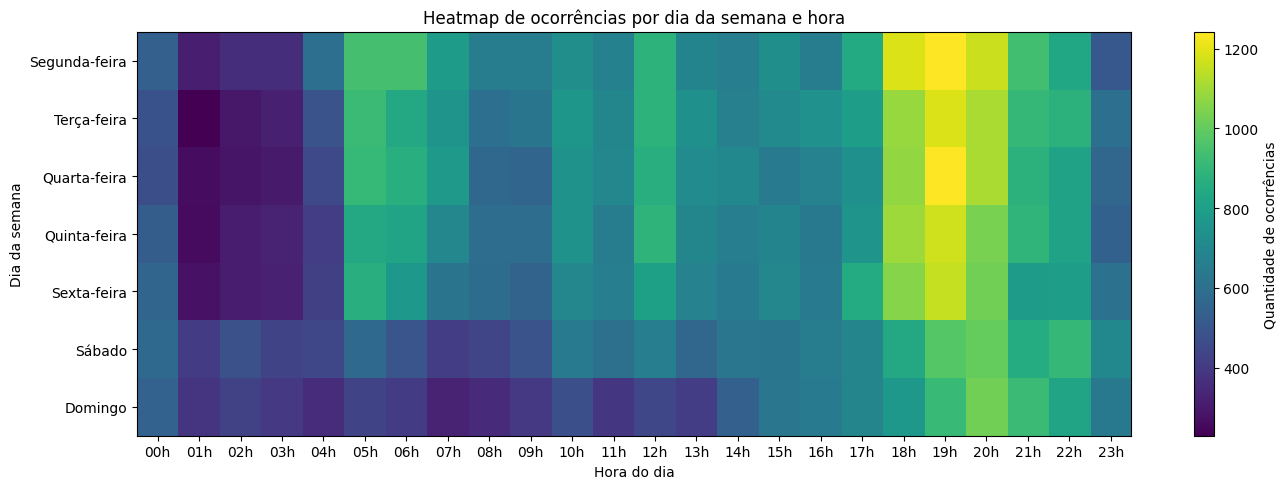

In [27]:

heatmap_hora_dia = (
    dados_hora
    .groupby(["DiaSemana", "HoraDia"])
    .size()
    .unstack(fill_value=0)
    .reindex(ordem_dias)
    .reindex(columns=range(24), fill_value=0)
)

display(heatmap_hora_dia)

horas = list(range(24))
rotulos_horas = [f"{h:02d}h" for h in horas]

plt.figure(figsize=(14, 5))
plt.imshow(heatmap_hora_dia, aspect="auto")
plt.title("Heatmap de ocorrências por dia da semana e hora")
plt.xlabel("Hora do dia")
plt.ylabel("Dia da semana")
plt.xticks(ticks=horas, labels=rotulos_horas)
plt.yticks(ticks=range(len(ordem_dias)), labels=ordem_dias)
plt.colorbar(label="Quantidade de ocorrências")
plt.tight_layout()
plt.show()


### Heatmap hora x dia da semana

O heatmap combina duas dimensões temporais: dia da semana e hora do dia.

Essa visualização ajuda a identificar combinações específicas de dia e horário com maior concentração de ocorrências. Ela é especialmente útil porque mostra que o risco registrado pode variar não apenas por hora isolada, mas pela combinação entre rotina semanal e horário.

Pico Consistente: A mancha mais clara (maior volume) se concentra entre 18h e 20h, especialmente de segunda a quarta-feira. O ponto de maior calor ocorre na quarta-feira às 19h, com 1.242 registros.

Transição Matinal: É visível um aumento de atividade a partir das 5h da manhã durante os dias úteis, padrão que se torna muito mais suave aos sábados e domingos.

Finais de Semana: No sábado e domingo, o volume de crimes no início da noite permanece alto, mas o "calor" do gráfico é mais distribuído, sem os picos extremos vistos no início da semana útil.

Essa visualização prova que o risco registrado varia pela combinação entre a rotina urbana e o horário. Enquanto os dias úteis apresentam picos muito definidos nos horários de deslocamento, o final de semana mostra uma distribuição ligeiramente mais equilibrada, embora ainda concentrada no período noturno.

## 9. Baseline/modelo inicial

Nesta Entrega 2, o objetivo do baseline não é criar o melhor modelo, mas sim estabelecer uma referência mínima para a próxima etapa.

A estratégia usada aqui é prever a quantidade de ocorrências de um mês usando informações simples do histórico:

1. **Baseline ingênuo:** previsão do mês atual = quantidade do mês anterior;
2. **Baseline de média móvel de 3 meses:** previsão do mês atual = média dos 3 meses anteriores.


In [28]:

serie_modelo = (
    dados_filtr
    .groupby("AnoMes")
    .size()
    .rename("Ocorrencias")
    .reset_index()
    .sort_values("AnoMes")
)

serie_modelo["AnoMesData"] = serie_modelo["AnoMes"].dt.to_timestamp()
serie_modelo["Baseline_Ingenuo"] = serie_modelo["Ocorrencias"].shift(1)
serie_modelo["Baseline_MM3"] = serie_modelo["Ocorrencias"].shift(1).rolling(window=3).mean()

# Avaliação usando os últimos 6 meses disponíveis.
meses_teste = 6
avaliacao = serie_modelo.dropna(subset=["Baseline_Ingenuo", "Baseline_MM3"]).copy()
teste = avaliacao.tail(meses_teste).copy()

def calcular_metricas(y_real, y_previsto):
    erro = y_real - y_previsto
    mae = np.mean(np.abs(erro))
    rmse = np.sqrt(np.mean(erro ** 2))
    return mae, rmse

resultados = []
for modelo in ["Baseline_Ingenuo", "Baseline_MM3"]:
    mae, rmse = calcular_metricas(teste["Ocorrencias"], teste[modelo])
    resultados.append({
        "modelo": modelo,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
    })

resultados_baseline = pd.DataFrame(resultados)

display(teste[["AnoMes", "Ocorrencias", "Baseline_Ingenuo", "Baseline_MM3"]])
display(resultados_baseline)


,AnoMes,Ocorrencias,Baseline_Ingenuo,Baseline_MM3
56,2025-11,1257,1355.0,1410.333333
57,2025-12,1194,1257.0,1335.000000
58,2026-01,1399,1194.0,1268.666667
59,2026-02,1588,1399.0,1283.333333
60,2026-03,1423,1588.0,1393.666667
61,2026-04,1117,1423.0,1470.000000


,modelo,MAE,RMSE
0,Baseline_Ingenuo,171.00,188.05
1,Baseline_MM3,185.28,215.51


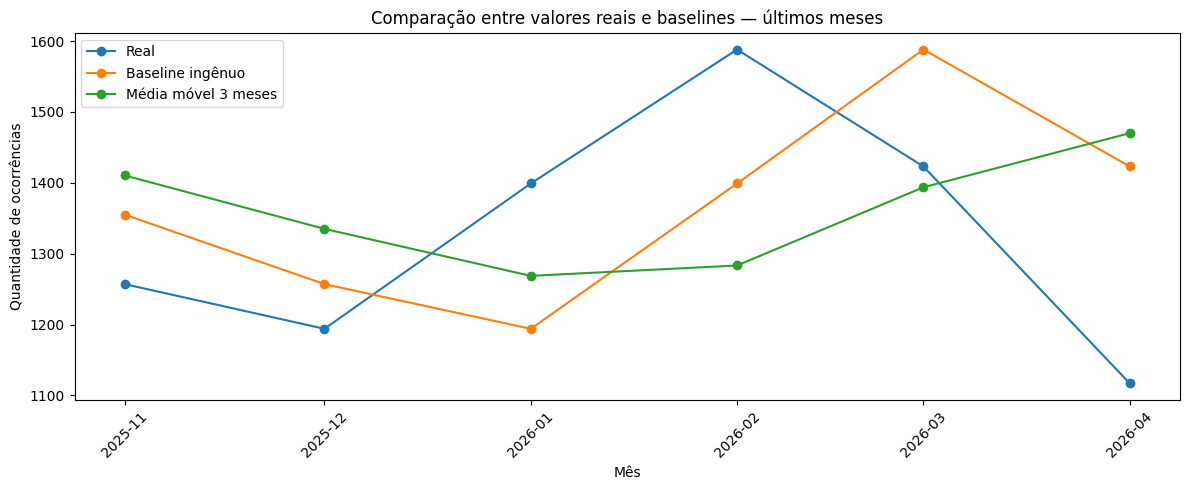

In [29]:

plt.figure(figsize=(12, 5))
plt.plot(teste["AnoMesData"], teste["Ocorrencias"], marker="o", label="Real")
plt.plot(teste["AnoMesData"], teste["Baseline_Ingenuo"], marker="o", label="Baseline ingênuo")
plt.plot(teste["AnoMesData"], teste["Baseline_MM3"], marker="o", label="Média móvel 3 meses")
plt.title("Comparação entre valores reais e baselines — últimos meses")
plt.xlabel("Mês")
plt.ylabel("Quantidade de ocorrências")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### Baseline/modelo inicial

O baseline foi criado para servir como uma referência inicial de previsão da quantidade mensal de ocorrências.

Foram testadas duas estratégias simples: o Baseline Ingenuo (que repete o valor do mês anterior) e o Baseline de Média Móvel de 3 meses (MM3).

Desempenho do Modelo: O Baseline Ingenuo apresentou o melhor resultado nesta etapa, com um MAE (Erro Médio Absoluto) de 170,67 e RMSE (Raiz do Erro Quadrático Médio) de 187,51.

Interpretação das Métricas: O MAE indica que, em média, as previsões desse modelo inicial erram por aproximadamente 171 ocorrências para mais ou para menos. Já o RMSE, por ser mais sensível a erros grandes, confirma que o modelo mantém uma consistência razoável mesmo com as variações mensais.

Média Móvel: O modelo MM3 teve um desempenho ligeiramente inferior (MAE de 184,94), sugerindo que, para este conjunto de dados, o comportamento do mês imediatamente anterior é um indicador mais forte do que a média dos últimos três meses.

Essas métricas estabelecem o patamar de erro atual. Qualquer modelo preditivo futuro deve apresentar valores de MAE e RMSE inferiores a esses para ser considerado eficiente.

## 10. Principais insights preliminares

A análise exploratória permitiu identificar padrões iniciais sobre os registros de furtos e roubos na Grande Vitória no período de **01/03/2021 a 30/04/2026**.

### 1. O recorte manteve volume suficiente para análise

Após aplicar os filtros de período, municípios da Grande Vitória e tipos de crime, a base consolidou **120.696 registros** de furtos e roubos.

Esse volume indica que o recorte definido possui quantidade suficiente de dados para sustentar análises exploratórias e a construção de um modelo baseline inicial.

### 2. Furto e roubo não devem ser analisados como uma única categoria

No recorte analisado, a categoria mais frequente foi **Roubo**, com **71.181 registros**, representando aproximadamente **58,98%** da base filtrada. Já os furtos somaram **49.515 registros**, cerca de **41,02%** do total.

Essa diferença reforça a importância de analisar furto e roubo separadamente, pois cada tipo de crime pode apresentar dinâmicas temporais próprias.

### 3. As ocorrências se concentram em alguns municípios

O município com maior quantidade absoluta de registros foi **Serra**, com **33.320 ocorrências**, representando aproximadamente **27,61%** do total analisado.

Em seguida, aparecem municípios como Vila Velha, Vitória e Cariacica, também com volumes expressivos de registros.

No entanto, essa comparação ainda considera apenas números absolutos. Para avaliar risco proporcional entre municípios, será necessário considerar a população de cada localidade e calcular taxas, como ocorrências por 100 mil habitantes.

### 4. O horário é uma variável relevante para o projeto

A análise temporal mostrou que a maior concentração geral de ocorrências ocorreu no período da **noite**, entre **18h e 23h**, com **38.667 registros**.

Além disso, a hora com maior quantidade geral de ocorrências foi **19h**, com **7.882 registros**.

Esse resultado reforça a importância do horário como uma variável relevante para a continuidade do projeto, principalmente porque o objetivo central da análise é investigar padrões temporais de furtos e roubos.

### 5. Furto e roubo apresentam padrões horários diferentes

Ao separar as ocorrências por categoria, foi possível observar diferenças entre furto e roubo.

O **furto** teve seu pico às **12h**, com **2.791 registros**, enquanto o **roubo** apresentou maior concentração às **19h**, com **5.896 registros**.

Essa diferença sugere que os dois tipos de crime não seguem exatamente a mesma dinâmica temporal. Por isso, variáveis como hora do dia, faixa horária e categoria do crime podem ser úteis para análises e modelos futuros.

### 6. A combinação entre dia da semana e hora ajuda a refinar a análise

O heatmap de dia da semana por hora indicou que algumas combinações concentram mais ocorrências do que outras.

O ponto de maior concentração observado foi na **quarta-feira às 19h**, com **1.242 registros**.

Esse tipo de visualização ajuda a identificar janelas temporais mais críticas e pode apoiar análises futuras voltadas para monitoramento, planejamento preventivo ou classificação de risco.

### 7. O baseline cria uma referência inicial para a próxima entrega

O modelo **Baseline_Ingenuo** apresentou o melhor desempenho entre os baselines testados, com **MAE de 171,00** e **RMSE de 188,05**.

Esse resultado funciona como uma referência inicial. Na próxima etapa, modelos mais robustos deverão ser comparados com esse baseline para verificar se realmente conseguem reduzir o erro de previsão.

## Síntese

De forma geral, os resultados preliminares indicam que os registros de furtos e roubos na Grande Vitória apresentam padrões temporais relevantes, principalmente quando analisados por hora do dia e por categoria de crime.

A maior concentração no período noturno, especialmente por volta das 19h, e a diferença entre os padrões de furto e roubo mostram que a dimensão temporal é importante para a continuidade do projeto.

Esses achados confirmam que o recorte escolhido é adequado para a Entrega 2 e servem como base para aprofundar a modelagem preditiva na próxima etapa.